In [318]:
# Import necessary libraries
import numpy as np
from sklearn.datasets import load_digits
from sklearn.cluster import KMeans
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
from sklearn.preprocessing import normalize
from scipy.sparse.linalg import svds
from scipy.linalg import eigh
from scipy.optimize import linear_sum_assignment
from sklearn.metrics.pairwise import pairwise_distances
import matplotlib.pyplot as plt
import optuna
from optuna import Trial
from optuna.samplers import TPESampler
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
import numpy as np



In [319]:
# Load the digits dataset
digits = load_digits()
X = digits.data  # Shape: (1797, 64)
y = digits.target  # True labels
N, d = X.shape
print(f"Dataset contains {N} samples with {d} features each.")


Dataset contains 1797 samples with 64 features each.


In [320]:
# Define the ACC metric using the Hungarian algorithm
def clustering_accuracy(y_true, y_pred):
    """
    Calculate clustering accuracy using the Hungarian algorithm.
    """
    y_true = y_true.astype(np.int64)
    assert y_pred.size == y_true.size
    D = max(y_pred.max(), y_true.max()) + 1
    w = np.zeros((D, D), dtype=np.int64)
    for i in range(y_pred.size):
        w[y_pred[i], y_true[i]] += 1
    ind = linear_sum_assignment(w.max() - w)
    return sum([w[i, j] for i, j in zip(*ind)]) / y_pred.size


In [321]:
# Parameters for FSEC
p = 100  # Number of anchors
K = 10   # Number of nearest anchors
m = 10   # Number of base clusterings


In [322]:
# Step 1: Anchor Selection using Balanced K-Means Hierarchical K-Means (BKHK)
# Since BKHK is not available in sklearn, we'll approximate it using a two-step k-means

def select_anchors_bkhk(X, p, random_state=42):
    """
    Approximate BKHK anchor selection using a two-step k-means approach.
    """
    from sklearn.cluster import MiniBatchKMeans

    # Step 1: Randomly select p' > p samples
    p_prime = 2 * p
    np.random.seed(random_state)
    indices = np.random.choice(N, p_prime, replace=False)
    X_subset = X[indices]

    # Step 2: Run k-means on the subset to get p anchors
    kmeans = KMeans(n_clusters=p, random_state=random_state)
    kmeans.fit(X_subset)
    anchors = kmeans.cluster_centers_
    return anchors

anchors = select_anchors_bkhk(X, p)
print(f"Selected {anchors.shape[0]} anchors.")


Selected 100 anchors.


In [323]:
# Step 2: Graph Construction

def construct_similarity_matrix(X, anchors, K=10, K_prime=100, gamma=None):
    """
    Construct the similarity matrix W based on the FSEC algorithm's description.
    
    Parameters:
    - X: Data matrix of shape (N, d)
    - anchors: Anchor points of shape (p, d)
    - K: Number of nearest anchors to select for each sample
    - K_prime: Number of nearest anchors to consider for each anchor (K' > K)
    - gamma: Regularization parameter (not used in the closed-form solution)
    
    Returns:
    - W: Sparse similarity matrix of shape (N, p)
    """
    import numpy as np
    from scipy.sparse import csr_matrix
    from sklearn.metrics import pairwise_distances
    from sklearn.preprocessing import normalize

    N, p = X.shape[0], anchors.shape[0]
    
    # Step 2.1: Compute distances between samples and anchors
    distances = pairwise_distances(X, anchors, metric='euclidean')  # Shape: (N, p)
    
    # Step 2.2: Assign each sample to its nearest anchor
    nearest_anchor = np.argmin(distances, axis=1)  # Shape: (N,)
    
    # Step 2.3: For each anchor, find its K' nearest anchors (excluding itself)
    anchor_distances = pairwise_distances(anchors, anchors, metric='euclidean')  # Shape: (p, p)
    
    # Adjust K_prime to not exceed p-1 and ensure it's at least K + 1
    K_prime = min(K_prime, p - 1)
    K_prime = max(K_prime, K + 1)
    
    # Find K_prime nearest anchors for each anchor (excluding itself)
    knn_anchor = np.argsort(anchor_distances, axis=1)[:, 1:K_prime + 1]  # Shape: (p, K_prime)
    
    # Step 2.4: For each sample, limit candidate anchors to K' neighbors of its assigned anchor
    candidate_anchors = knn_anchor[nearest_anchor]  # Shape: (N, K_prime)
    
    # Step 2.5: Compute distances to candidate anchors
    # Advanced indexing to gather the distances
    row_indices = np.arange(N)[:, np.newaxis]  # Shape: (N, 1)
    candidate_distances = distances[row_indices, candidate_anchors]  # Shape: (N, K_prime)
    
    # Step 2.6: Select K nearest anchors from candidates
    top_k_indices = np.argsort(candidate_distances, axis=1)[:, :K]  # Shape: (N, K)
    final_anchors = candidate_anchors[np.arange(N)[:, None], top_k_indices]  # Shape: (N, K)
    final_distances = np.take_along_axis(candidate_distances, top_k_indices, axis=1)  # Shape: (N, K)
    
    # Step 2.7: Compute b_ij using the closed-form solution (Equation 3)
    # Compute d(i, K) and d(i, K+1)
    
    # d(i, K) is the K-th smallest distance for each sample
    d_i_K = final_distances[:, -1]  # Shape: (N,)
    
    # d(i, K+1) is the (K+1)-th smallest distance for each sample
    # Using np.partition to efficiently find the (K+1)-th smallest distance
    d_i_K_plus_1 = np.partition(distances, K + 1, axis=1)[:, K + 1]  # Shape: (N,)
    
    # Compute the sum of the first K distances for each sample
    sum_d_i_K = np.sum(np.partition(distances, K, axis=1)[:, :K], axis=1)  # Shape: (N,)
    
    # Compute the denominator of b_ij
    epsilon = 1e-10  # Small constant to prevent division by zero
    denominator = (K * d_i_K_plus_1 - sum_d_i_K) + epsilon  # Shape: (N,)
    
    # Compute b_ij as per Equation (3)
    b_ij = (d_i_K_plus_1 - d_i_K) / denominator  # Shape: (N,)
    
    # Ensure that b_ij is non-negative
    b_ij = np.maximum(b_ij, 0)  # Shape: (N,)
    
    # Step 2.8: Construct W as a sparse matrix
    # Each sample is connected to its K nearest anchors with similarity b_ij
    # W[i, j] = b_ij for each of the K anchors j for sample i
    data = np.repeat(b_ij, K)  # Shape: (N * K,)
    row_indices = np.repeat(np.arange(N), K)  # Shape: (N * K,)
    col_indices = final_anchors.flatten()  # Shape: (N * K,)
    
    # Create the sparse similarity matrix
    W = csr_matrix((data, (row_indices, col_indices)), shape=(N, p))  # Shape: (N, p)
    
    # Normalize W to make it double stochastic
    # First, perform row-wise normalization to ensure each row sums to 1
    W = normalize(W, norm='l1', axis=1)
    
    # Then, perform column-wise normalization to ensure each column sums to 1
    W = normalize(W, norm='l1', axis=0)
    
    # Convert back to sparse format
    W = csr_matrix(W)
    
    return W


# Apply the corrected function
W = construct_similarity_matrix(X, anchors, K=10, K_prime=100)
print("Constructed similarity matrix W.")


Constructed similarity matrix W.


In [324]:
# Step 3: Generate Base Clusterings

def generate_base_clusterings(W, m=10, random_state=42):
    """
    Generate base clusterings using SVD and k-means.
    """
    # Step 3.1: Perform SVD on W
    Z = W  # Since W is already double stochastic and W = Z Z^T
    U, S, Vt = svds(Z, k=min(50, int(np.sqrt(N))))
    U = U[:, ::-1]  # Descending order
    S = S[::-1]
    F = U  # Indicator matrix approximation

    # Step 3.2: Generate base clusterings with varying number of clusters
    base_clusterings = []
    for i in range(m):
        c_i = np.random.randint(2, 15)  # Random number of clusters between 2 and 15
        kmeans = KMeans(n_clusters=c_i, random_state=42 + i)
        labels = kmeans.fit_predict(F)
        base_clusterings.append(labels)
    return base_clusterings

base_clusterings = generate_base_clusterings(W, m=10)
print(f"Generated {len(base_clusterings)} base clusterings.")


Generated 10 base clusterings.


In [325]:
# Step 4: Partition Bipartite Graph and Obtain Final Clustering

def partition_bipartite_graph(base_clusterings, p, k_final=10, random_state=42):
    """
    Construct the bipartite graph and perform consensus partition.

    Returns:
    - final_labels: Final clustering labels after consensus
    """
    # Construct Psi (set of all clusters from base clusterings)
    Psi = []
    for clustering in base_clusterings:
        unique_clusters = np.unique(clustering)
        Psi.extend(unique_clusters)
    C = len(Psi)  # Total number of unique clusters across all base clusterings

    # Construct similarity matrix tilde_E (binary matrix indicating sample-cluster membership)
    tilde_E = np.zeros((N, C), dtype=int)
    cluster_idx = 0
    for clustering in base_clusterings:
        unique_clusters = np.unique(clustering)
        for cluster_label in unique_clusters:
            tilde_E[np.where(clustering == cluster_label)[0], cluster_idx] = 1
            cluster_idx += 1

    # Construct tilde_A
    sum_per_sample = np.sum(tilde_E, axis=1)  # Shape: (N,)
    
    # Avoid division by zero by setting zeros to epsilon
    epsilon = 1e-10
    sum_per_sample[sum_per_sample == 0] = epsilon
    
    D_B_inv = np.diag(1.0 / sum_per_sample)  # Shape: (N, N)
    
    # Compute tilde_A = tilde_E.T @ D_B_inv @ tilde_E
    tilde_A = tilde_E.T @ D_B_inv @ tilde_E  # Shape: (C, C)

    # Compute Laplacian of tilde_A
    tilde_D = np.diag(np.sum(tilde_A, axis=1))  # Shape: (C, C)
    tilde_L = tilde_D - tilde_A  # Shape: (C, C)

    # Perform eigen decomposition on tilde_L
    eigen_vals, eigen_vecs = eigh(tilde_L)  # eigen_vals sorted in ascending order

    # Select the first k_final eigenvectors (smallest eigenvalues)
    F_u = eigen_vecs[:, :k_final]  # Shape: (C, k_final)
    lambda_vals = eigen_vals[:k_final]  # Shape: (k_final,)

    # Compute f = [v, u]
    # v = (1 / (1 - lambda)) * D_B^{-1} * tilde_E * u
    # Compute D_B^{-1} * tilde_E
    D_B_inv_tilde_E = D_B_inv @ tilde_E  # Shape: (N, C)
    
    # Multiply by u (F_u)
    v = D_B_inv_tilde_E @ F_u  # Shape: (N, k_final)
    
    # Compute scaling factors (1 / (1 - lambda))
    scaling_factors = 1.0 / (1.0 - lambda_vals)  # Shape: (k_final,)
    
    # Multiply v by scaling factors
    v_scaled = v * scaling_factors  # Shape: (N, k_final)

    # f = [v_scaled, F_u]
    # Since we only need features for samples, we'll use v_scaled
    F_final = v_scaled  # Shape: (N, k_final)

    # Normalize F_final
    F_final = normalize(F_final, norm='l2', axis=1)  # Shape: (N, k_final)

    # Run k-means on F_final to get final clustering
    kmeans_final = KMeans(n_clusters=k_final, random_state=random_state)
    final_labels = kmeans_final.fit_predict(F_final)  # Shape: (N,)

    return final_labels

# Apply the corrected function
final_labels = partition_bipartite_graph(base_clusterings, p=100)
print("Obtained final clustering labels.")


Obtained final clustering labels.


In [326]:
# Step 5: Evaluation Metrics

# Calculate NMI
nmi = normalized_mutual_info_score(y, final_labels)
print(f"NMI (Normalized Mutual Information): {nmi:.4f}")

# Calculate ARI
ari = adjusted_rand_score(y, final_labels)
print(f"ARI (Adjusted Rand Index): {ari:.4f}")

# Calculate ACC
accuracy = clustering_accuracy(y, final_labels)
print(f"ACC (Clustering Accuracy): {accuracy:.4f}")


NMI (Normalized Mutual Information): 0.2500
ARI (Adjusted Rand Index): 0.0327
ACC (Clustering Accuracy): 0.2732


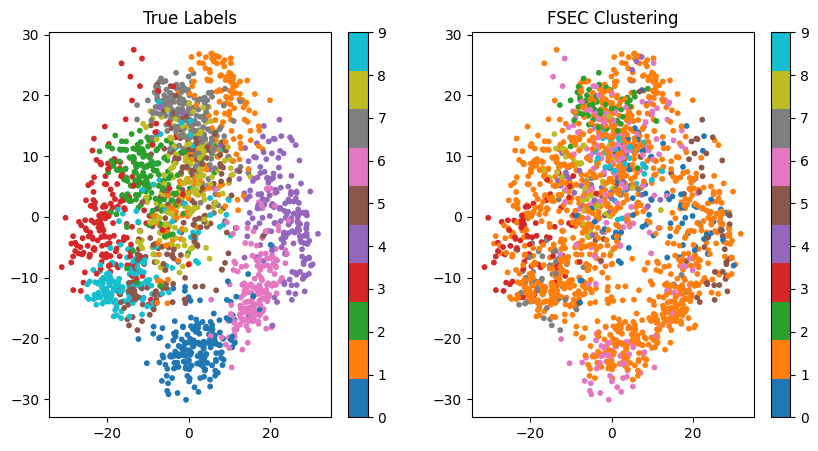

In [327]:
# Optional: Visualize the final clustering using PCA

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
plt.figure(figsize=(10, 5))

# True Labels
plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', s=10)
plt.title('True Labels')
plt.colorbar()

# FSEC Clustering
plt.subplot(1, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=final_labels, cmap='tab10', s=10)
plt.title('FSEC Clustering')
plt.colorbar()

plt.show()


In [328]:
def fsec_clustering(X, y, p, K, m, K_prime, k_final=10, random_state=42):
    """
    Perform Anchor-based Fast Spectral Ensemble Clustering (FSEC).

    Parameters:
    - X: Data matrix of shape (N, d)
    - y: True labels (for evaluation)
    - p: Number of anchors
    - K: Number of nearest anchors per sample
    - m: Number of base clusterings
    - K_prime: Number of nearest anchors to consider for each anchor
    - k_final: Number of final clusters
    - random_state: Seed for reproducibility

    Returns:
    - metrics: Dictionary containing NMI, ARI, and ACC
    """
    from sklearn.cluster import KMeans
    from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
    from scipy.sparse import csr_matrix
    from scipy.linalg import eigh
    from sklearn.preprocessing import normalize

    N, d = X.shape

    # Step 1: Anchor Selection using Balanced K-Means Hierarchical K-Means (BKHK) Approximation
    anchors = select_anchors_bkhk(X, p, random_state)
    # print(f"Selected {anchors.shape[0]} anchors.")

    # Step 2: Graph Construction
    W = construct_similarity_matrix(X, anchors, K=K, K_prime=K_prime)
    # print("Constructed similarity matrix W.")

    # Step 3: Generate Base Clusterings
    base_clusterings = generate_base_clusterings(W, m=m, random_state=random_state)
    # print(f"Generated {len(base_clusterings)} base clusterings.")

    # Step 4: Partition Bipartite Graph and Obtain Final Clustering
    final_labels = partition_bipartite_graph(base_clusterings, p, k_final=k_final, random_state=random_state)
    # print("Obtained final clustering labels.")

    # Step 5: Evaluation Metrics
    # Calculate NMI, ARI, and ACC
    nmi = normalized_mutual_info_score(y, final_labels)
    ari = adjusted_rand_score(y, final_labels)
    acc = clustering_accuracy(y, final_labels)

    metrics = {
        'NMI': nmi,
        'ARI': ari,
        'ACC': acc
    }

    return metrics


In [329]:
def objective(trial: Trial):
    """
    Objective function for Optuna to optimize FSEC hyperparameters.

    Parameters:
    - trial: Optuna Trial object

    Returns:
    - nmi: Normalized Mutual Information score to maximize
    """
    # Hyperparameter suggestions
    p = trial.suggest_int('p', 50, 200)          # Number of anchors
    K = trial.suggest_int('K', 5, 20)           # Number of nearest anchors per sample
    m = trial.suggest_int('m', 5, 20)           # Number of base clusterings
    k_final = trial.suggest_int('k_final', 5, 15)  # Number of final clusters
    K_prime_ratio = trial.suggest_float('K_prime_ratio', 1.1, 10.0)  # Ratio to scale K

    # Calculate K_prime based on K_prime_ratio and K
    K_prime = int(np.round(K * K_prime_ratio))

    # Ensure K_prime is at least K + 1 and does not exceed p - 1
    K_prime = max(K + 1, K_prime)
    K_prime = min(K_prime, p - 1)

    # Run FSEC with suggested hyperparameters
    metrics = fsec_clustering(X, y, p=p, K=K, m=m, K_prime=K_prime, k_final=k_final, random_state=42)

    # You can choose to optimize any of the metrics; here we'll optimize NMI
    return metrics['NMI']


In [330]:
# Create an Optuna study
study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))

# Optimize the study with a specified number of trials
study.optimize(objective, n_trials=50, timeout=3600)  # Adjust n_trials and timeout as needed


[I 2024-11-22 05:44:04,279] A new study created in memory with name: no-name-db9f2a1f-92ee-4ee2-b66d-a0d68a80be2b
[I 2024-11-22 05:44:04,807] Trial 0 finished with value: 0.20850502618469496 and parameters: {'p': 106, 'K': 20, 'm': 16, 'k_final': 11, 'K_prime_ratio': 2.488565899937685}. Best is trial 0 with value: 0.20850502618469496.
[I 2024-11-22 05:44:05,286] Trial 1 finished with value: 0.21611225579491233 and parameters: {'p': 73, 'K': 5, 'm': 18, 'k_final': 11, 'K_prime_ratio': 7.401845942384805}. Best is trial 1 with value: 0.21611225579491233.
[I 2024-11-22 05:44:05,755] Trial 2 finished with value: 0.26726883021277775 and parameters: {'p': 53, 'K': 20, 'm': 18, 'k_final': 7, 'K_prime_ratio': 2.7182422081431956}. Best is trial 2 with value: 0.26726883021277775.
[I 2024-11-22 05:44:06,163] Trial 3 finished with value: 0.24001421495897798 and parameters: {'p': 77, 'K': 9, 'm': 13, 'k_final': 9, 'K_prime_ratio': 3.691939347762573}. Best is trial 2 with value: 0.26726883021277775.


In [331]:
# Get the best trial
best_trial = study.best_trial

print("Best Trial:")
print(f"  Value (NMI): {best_trial.value}")
print("  Params:")
for key, value in best_trial.params.items():
    print(f"    {key}: {value}")


Best Trial:
  Value (NMI): 0.45979822686424465
  Params:
    p: 121
    K: 17
    m: 11
    k_final: 12
    K_prime_ratio: 8.379648527711504


In [332]:
import optuna.visualization as vis

# Plot the optimization history
vis.plot_optimization_history(study)


In [333]:
# Plot the parameter importances
vis.plot_param_importances(study)


In [334]:
# Extract best hyperparameters
best_p = best_trial.params['p']
best_K = best_trial.params['K']
best_m = best_trial.params['m']
best_k_final = best_trial.params['k_final']
best_K_prime_ratio = best_trial.params['K_prime_ratio']

# Calculate K_prime based on the best K_prime_ratio and K
best_K_prime = int(np.round(best_K * best_K_prime_ratio))
best_K_prime = max(best_K + 1, best_K_prime)
best_K_prime = min(best_K_prime, best_p - 1)

# Run FSEC with best hyperparameters
best_metrics = fsec_clustering(X, y, p=best_p, K=best_K, m=best_m, K_prime=best_K_prime, k_final=best_k_final, random_state=42)

print("Best Hyperparameters:")
print(f"  p (Number of Anchors): {best_p}")
print(f"  K (Nearest Anchors per Sample): {best_K}")
print(f"  K_prime_ratio: {best_K_prime_ratio}")
print(f"  K_prime (Number of Nearest Anchors to Consider): {best_K_prime}")
print(f"  m (Number of Base Clusterings): {best_m}")
print(f"  k_final (Number of Final Clusters): {best_k_final}")

print("\nBest Clustering Metrics:")
print(f"  NMI: {best_metrics['NMI']:.4f}")
print(f"  ARI: {best_metrics['ARI']:.4f}")
print(f"  ACC: {best_metrics['ACC']:.4f}")


Best Hyperparameters:
  p (Number of Anchors): 121
  K (Nearest Anchors per Sample): 17
  K_prime_ratio: 8.379648527711504
  K_prime (Number of Nearest Anchors to Consider): 120
  m (Number of Base Clusterings): 11
  k_final (Number of Final Clusters): 12

Best Clustering Metrics:
  NMI: 0.4598
  ARI: 0.1925
  ACC: 0.3478


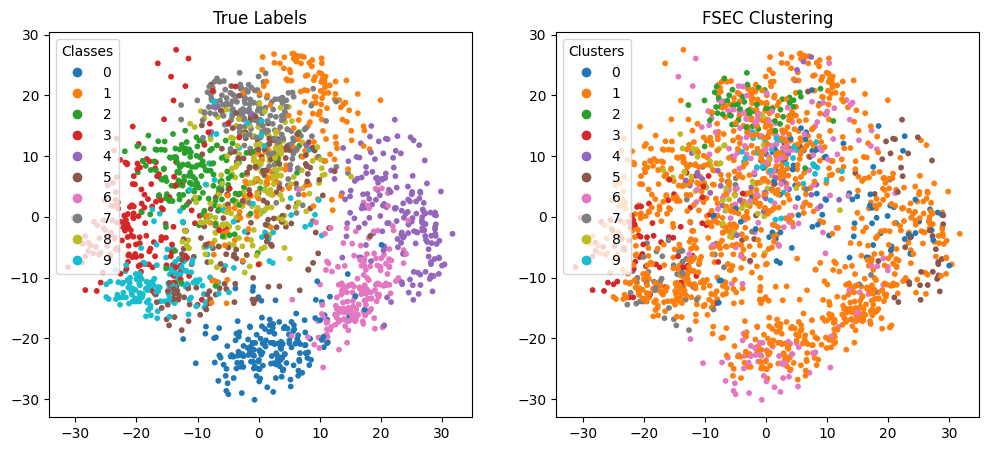

In [335]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Reduce dimensionality for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

# Plot True Labels vs. FSEC Clustering
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# True Labels
scatter = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', s=10)
axes[0].set_title('True Labels')
axes[0].legend(*scatter.legend_elements(), title="Classes")

# FSEC Clustering
scatter = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=final_labels, cmap='tab10', s=10)
axes[1].set_title('FSEC Clustering')
axes[1].legend(*scatter.legend_elements(), title="Clusters")

plt.show()
